In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [65]:
def data_augmentation(is_train):
    if is_train:
        transform = transforms.Compose([
            transforms.RandomRotation(10),
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),

            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    else:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    return transform

In [66]:
train = datasets.CIFAR10(root = './data', train=True, download=True, transform=data_augmentation(True))
test = datasets.CIFAR10(root = './data', train=False, download=True, transform=data_augmentation(False))

In [69]:
test

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [42]:
import multiprocessing
multiprocessing.cpu_count()

16

In [43]:
train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=8)
test_loader = DataLoader(test, batch_size=64, num_workers=8)


In [44]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_lyr = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.4)
        )

        self.fc_lyr = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*4*256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout1d(0.3),

            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.conv_lyr(x)
        x = x.view(x.size(0), -1)
        x = self.fc_lyr(x)
        
        return x

In [45]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters())
critrion = nn.CrossEntropyLoss()

In [ ]:
model.train()

epochs = 25
best_acc = 0.0

for epoch in range(epochs):
    train_loss = 0.0
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = critrion(output, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    # print(f'Epoch {epoch+1}, loss is : {train_loss/len(train_loader)}')
        

    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            _, pred = torch.max(output, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
        
        
        val_acc = correct/total*100
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            
        print(f'Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%')

    

Epoch 1 | Loss: 1.0231 | Val Acc: 85.13%
Epoch 2 | Loss: 0.3485 | Val Acc: 84.93%
Epoch 3 | Loss: 0.3176 | Val Acc: 84.97%
Epoch 4 | Loss: 0.2947 | Val Acc: 86.20%
Epoch 5 | Loss: 0.2790 | Val Acc: 86.58%
Epoch 6 | Loss: 0.2625 | Val Acc: 85.55%
Epoch 7 | Loss: 0.2493 | Val Acc: 85.96%
Epoch 8 | Loss: 0.2374 | Val Acc: 86.01%
Epoch 9 | Loss: 0.2260 | Val Acc: 86.74%
Epoch 10 | Loss: 0.2147 | Val Acc: 87.34%
Epoch 11 | Loss: 0.2040 | Val Acc: 86.11%
Epoch 12 | Loss: 0.1934 | Val Acc: 86.81%
Epoch 13 | Loss: 0.1885 | Val Acc: 87.35%
Epoch 14 | Loss: 0.1809 | Val Acc: 87.10%
Epoch 15 | Loss: 0.1756 | Val Acc: 86.76%
Epoch 16 | Loss: 0.1674 | Val Acc: 86.54%
Epoch 17 | Loss: 0.1627 | Val Acc: 87.49%
Epoch 18 | Loss: 0.1595 | Val Acc: 86.64%
Epoch 19 | Loss: 0.1532 | Val Acc: 87.51%
Epoch 20 | Loss: 0.1432 | Val Acc: 86.82%
Epoch 21 | Loss: 0.1384 | Val Acc: 87.20%
Epoch 22 | Loss: 0.1365 | Val Acc: 87.19%
Epoch 23 | Loss: 0.1325 | Val Acc: 87.05%
Epoch 24 | Loss: 0.1276 | Val Acc: 86.89%
E

In [54]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

CNN(
  (conv_lyr): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.3, inpl

In [70]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def predict_single(index):

    image, label = test[index]
    img_show = image.permute(1, 2, 0)
    img_show = img_show * 0.5 + 0.5
    plt.imshow(img_show)
    plt.show()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim = 1)
        conf, pred = torch.max(probs, 1)

    print('True Label : ', classes[label])
    print('Predicted : ', classes[pred.item()])
    print(f'Confidance : {conf.item()*100:.2f}%')

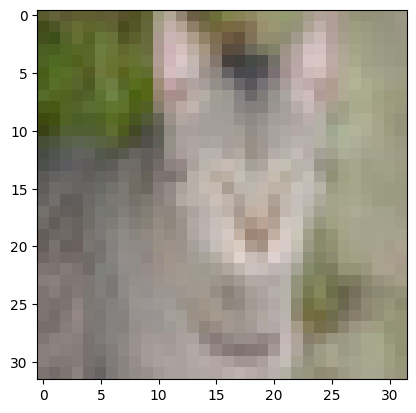

True Label :  cat
Predicted :  cat
Confidance : 100.00%


In [71]:
predict_single(320)